<a href="https://colab.research.google.com/github/nmach22/movie-sentiment-analysis/blob/main/notebooks/colab_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab environment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pip install kaggle -q

### Set up Kaggle API credentials

To download datasets from Kaggle, you need an API key. Follow these steps:

1. Go to [Kaggle](https://www.kaggle.com/).
2. Log in to your account.
3. Click on your profile picture in the top right corner and select "My Account".
4. Scroll down to the "API" section and click "Create New API Token". This will download a `kaggle.json` file.
5. Upload this `kaggle.json` file to your Colab environment using the file upload button on the left sidebar (folder icon) or by running the following Python code to open an upload dialog.

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nmach22","key":"1bcaaf4b5ace614578f4d815af992b7e"}'}

In [4]:
import os

# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move kaggle.json to the .kaggle directory
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
import kaggle

competition_name = 'sentiment-analysis-on-movie-reviews'

print(f"Downloading files for competition: {competition_name}")
kaggle.api.competition_download_files(competition_name, path='./')
print("Download complete.")

Download complete.


In [6]:
import zipfile

# Get a list of all zip files in the current directory
zip_files = [f for f in os.listdir('./') if f.endswith('.zip')]

# Unzip each file
for zip_file in zip_files:
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('./')
    print(f"Unzipped {zip_file}")

print("All files unzipped.")

Unzipped sentiment-analysis-on-movie-reviews.zip
All files unzipped.


In [7]:
print("Files in the current directory after unzipping:")
!ls -F

Files in the current directory after unzipping:
sample_data/	      sentiment-analysis-on-movie-reviews.zip  train.tsv.zip
sampleSubmission.csv  test.tsv.zip


In [8]:
import zipfile
import os

# Get a list of all remaining zip files (excluding the main competition zip and already processed zips)
remaining_zip_files = [f for f in os.listdir('./') if f.endswith('.zip') and f not in ['sentiment-analysis-on-movie-reviews.zip']]

if remaining_zip_files:
    print("Unzipping remaining data files:")
    for zip_file in remaining_zip_files:
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall('./')
        print(f"Unzipped {zip_file}")
    print("All remaining files unzipped.")
else:
    print("No additional zip files found to unzip.")

print("Files in the current directory after further unzipping:")
!ls -F

Unzipping remaining data files:
Unzipped train.tsv.zip
Unzipped test.tsv.zip
All remaining files unzipped.
Files in the current directory after further unzipping:
sample_data/				 test.tsv      train.tsv.zip
sampleSubmission.csv			 test.tsv.zip
sentiment-analysis-on-movie-reviews.zip  train.tsv


In [9]:
import zipfile
import os

# Get a list of all remaining zip files (excluding the main competition zip)
remaining_zip_files = [f for f in os.listdir('./') if f.endswith('.zip') and f != 'sentiment-analysis-on-movie-reviews.zip']

if remaining_zip_files:
    print("Unzipping remaining data files:")
    for zip_file in remaining_zip_files:
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall('./')
        print(f"Unzipped {zip_file}")
    print("All remaining files unzipped.")
else:
    print("No additional zip files found to unzip.")

print("Files in the current directory after further unzipping:")
!ls -F

Unzipping remaining data files:
Unzipped train.tsv.zip
Unzipped test.tsv.zip
All remaining files unzipped.
Files in the current directory after further unzipping:
sample_data/				 test.tsv      train.tsv.zip
sampleSubmission.csv			 test.tsv.zip
sentiment-analysis-on-movie-reviews.zip  train.tsv


# explore dataset

In [10]:
df = pd.read_csv('train.tsv', sep='\t')

In [11]:
df.head()

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


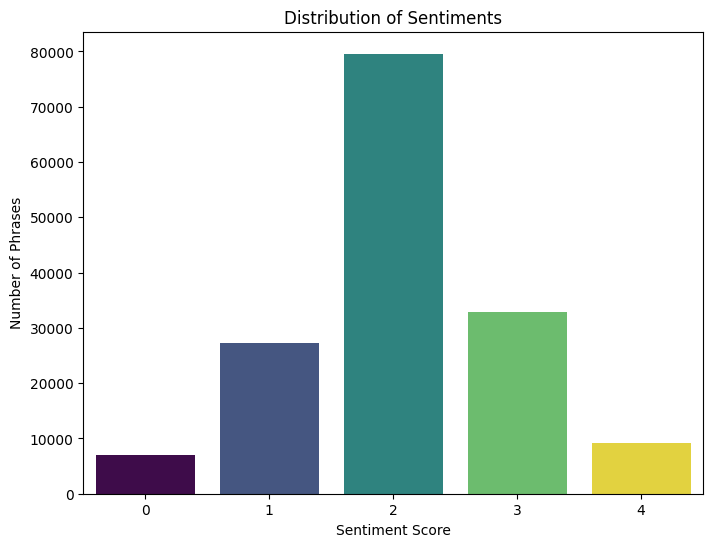

In [12]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=df, palette='viridis', hue='Sentiment', legend=False)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment Score')
plt.ylabel('Number of Phrases')
plt.show()

In [13]:
print("Missing values per column:")
display(df.isnull().sum())

print("\nTotal missing values in the DataFrame:")
display(df.isnull().sum().sum())

Missing values per column:


,0
PhraseId,0
SentenceId,0
Phrase,0
Sentiment,0



Total missing values in the DataFrame:


np.int64(0)

In [14]:
print("Summary statistics for the DataFrame:")
display(df.describe())

Summary statistics for the DataFrame:


,PhraseId,SentenceId,Sentiment
count,156060.000000,156060.000000,156060.000000
mean,78030.500000,4079.732744,2.063578
std,45050.785842,2502.764394,0.893832
min,1.000000,1.000000,0.000000
25%,39015.750000,1861.750000,2.000000
50%,78030.500000,4017.000000,2.000000
75%,117045.250000,6244.000000,3.000000
max,156060.000000,8544.000000,4.000000


# split

In [15]:
train_df = pd.read_csv('train.tsv', sep='\t')

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(train_df['Phrase'], train_df['Sentiment'], test_size=0.2, random_state=42)

print(f"Train phrases: {X_train.shape[0]} samples")
print(f"Validation phrases: {X_val.shape[0]} samples")
print(f"Train sentiments: {y_train.shape[0]} samples")
print(f"Validation sentiments: {y_val.shape[0]} samples")

Train phrases: 124848 samples
Validation phrases: 31212 samples
Train sentiments: 124848 samples
Validation sentiments: 31212 samples


In [17]:
X_train.head()

,Phrase
22538,cheesy
99237,unintentionally -RRB-
60377,will need all the luck they can muster just fi...
128317,somewhere between Sling Blade and South of Hea...
20776,reminds at every turn of Elizabeth Berkley 's ...


### Text Preprocessing & Tokenization

In [18]:
import re

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.split()

X_train_tok = X_train.apply(tokenize)
X_val_tok   = X_val.apply(tokenize)

train_mask = X_train_tok.apply(len) > 0
val_mask   = X_val_tok.apply(len)   > 0

X_train_tok = X_train_tok[train_mask]
y_train     = y_train[train_mask]

X_val_tok   = X_val_tok[val_mask]
y_val       = y_val[val_mask]

print(f"Dropped {(~train_mask).sum()} empty train samples")
print(f"Dropped {(~val_mask).sum()} empty val samples")

Dropped 21 empty train samples
Dropped 6 empty val samples


### build vocabulary

In [19]:
from collections import Counter

PAD_IDX, UNK_IDX = 0, 1

counter = Counter(token for tokens in X_train_tok for token in tokens)

# Optional: drop rare words
vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
for word, freq in counter.items():
    if freq >= 2:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)

### Numericalize & Pad Sequences

In [20]:
import torch
from torch.nn.utils.rnn import pad_sequence

def encode(tokens):
    return [vocab.get(t, UNK_IDX) for t in tokens]

def to_tensor_and_lengths(encoded_series):
    encoded_list = [encode(t) for t in encoded_series]
    lengths = torch.tensor([len(t) for t in encoded_list], dtype=torch.long)
    tensors = [torch.tensor(t, dtype=torch.long) for t in encoded_list]
    padded_tensors = pad_sequence(tensors, batch_first=True, padding_value=PAD_IDX)
    return padded_tensors, lengths

X_train_tensor, X_train_lengths = to_tensor_and_lengths(X_train_tok)
X_val_tensor, X_val_lengths     = to_tensor_and_lengths(X_val_tok)
y_train_tensor                  = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor                    = torch.tensor(y_val.values,   dtype=torch.long)

## Chackpoints

In [21]:
import os

def save_checkpoint(model, optimizer, scheduler, epoch, val_acc, path="checkpoints"):
    os.makedirs(path, exist_ok=True)
    torch.save({
        "epoch":            epoch,
        "model_state":      model.state_dict(),
        "optimizer_state":  optimizer.state_dict(),
        "scheduler_state":  scheduler.state_dict(),
        "val_acc":          val_acc,
    }, f"{path}/epoch_{epoch}_acc{val_acc:.4f}.pt")

def load_checkpoint(path, model, optimizer=None, scheduler=None):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint["model_state"])
    if optimizer:
        optimizer.load_state_dict(checkpoint["optimizer_state"])
    if scheduler:
        scheduler.load_state_dict(checkpoint["scheduler_state"])
    print(f"Restored → Epoch {checkpoint['epoch']} | Val Acc {checkpoint['val_acc']:.4f}")
    return checkpoint["epoch"], checkpoint["val_acc"]

## Create Dataset & DataLoader

In [22]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 1024

train_loader = DataLoader(
    TensorDataset(X_train_tensor, X_train_lengths, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,        # parallel data loading
    pin_memory=True       # faster CPU→GPU transfer
    )

val_loader = DataLoader(
    TensorDataset(X_val_tensor, X_val_lengths, y_val_tensor),
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True
    )

## Define the RNN Model

In [23]:
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence


class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=n_layers,
                          batch_first=True)
        # Swap nn.RNN for nn.LSTM or nn.GRU for better results
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)          # (batch, seq, embed_dim)
        _, hidden = self.rnn(embedded)        # hidden: (n_layers, batch, hidden_dim)
        out = self.fc(hidden[-1])             # use last hidden state
        return out


class LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                   batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)          # (batch, seq, embed_dim)
        _, (hidden, _) = self.lstm(embedded)   # hidden: (n_layers, batch, hidden_dim)
        out = self.fc(hidden[-1])             # use last hidden state
        return out


class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 output_dim=5, n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                                 batch_first=True, dropout=dropout,
                                 bidirectional=True)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, output_dim)  # *2 for bidirectional

        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        self.embedding.weight.data[PAD_IDX].zero_()

    def forward(self, x, lengths=None):
        embedded = self.dropout(self.embedding(x))

        if lengths is not None:
            packed = pack_padded_sequence(embedded, lengths.cpu().clamp(min=1),
                                          batch_first=True, enforce_sorted=False)
            _, (hidden, _) = self.lstm(packed)
        else:
            # fallback: infer lengths from non-padding tokens
            lengths = (x != PAD_IDX).sum(dim=1).clamp(min=1)
            packed  = pack_padded_sequence(embedded, lengths.cpu(),
                                          batch_first=True, enforce_sorted=False)
            _, (hidden, _) = self.lstm(packed)

        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(hidden))


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # should print: cuda

cuda


In [25]:
import torch.optim as optim

model = SentimentLSTM(vocab_size=VOCAB_SIZE, embed_dim=128,
                     hidden_dim=256, output_dim=5, n_layers=2, dropout=0.3).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [26]:
nn.init.uniform_(model.embedding.weight, -0.1, 0.1)
# Reset padding row to zeros
model.embedding.weight.data[PAD_IDX].zero_()

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')

In [27]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

In [28]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Total number of parameters: 4457221


### Train the Model

In [29]:
EPOCHS       = 20
best_val_acc = 0.0
patience     = 0
MAX_PATIENCE = 4   # early stopping

CHECKPOINT_DIR = "/content/drive/MyDrive/movie_sentiment_checkpoints"

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, len_batch, y_batch in loader:
        X_batch   = X_batch.to(device)     # ← move here
        len_batch = len_batch.to(device)
        y_batch   = y_batch.to(device)     # ← and here

        optimizer.zero_grad()
        preds = model(X_batch, len_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (preds.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, len_batch, y_batch in loader:
            X_batch   = X_batch.to(device)
            len_batch = len_batch.to(device)
            y_batch   = y_batch.to(device)

            preds = model(X_batch, len_batch)
            total_loss += criterion(preds, y_batch).item()
            correct    += (preds.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)



for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc = eval_epoch(model, val_loader)
    scheduler.step(vl_acc)

    print(f"Epoch {epoch:02d} | Train {tr_acc:.4f} | Val {vl_acc:.4f}")

    # ── Save every epoch (optional, comment out if disk is tight) ──
    save_checkpoint(model, optimizer, scheduler, epoch, vl_acc)

    # ── Save best separately, always overwrite ──
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience     = 0
        torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/best_model.pt")
        print(f"  ✓ New best saved ({best_val_acc:.4f})")
    else:
        patience += 1
        print(f"  No improvement ({patience}/{MAX_PATIENCE})")
        if patience >= MAX_PATIENCE:
            print("Early stopping triggered.")
            break


Epoch 01 | Train 0.5296 | Val 0.5702
  ✓ New best saved (0.5702)
Epoch 02 | Train 0.6270 | Val 0.6522
  ✓ New best saved (0.6522)
Epoch 03 | Train 0.6800 | Val 0.6624
  ✓ New best saved (0.6624)
Epoch 04 | Train 0.6989 | Val 0.6646
  ✓ New best saved (0.6646)
Epoch 05 | Train 0.7119 | Val 0.6604
  No improvement (1/4)
Epoch 06 | Train 0.7235 | Val 0.6640
  No improvement (2/4)
Epoch 07 | Train 0.7342 | Val 0.6673
  ✓ New best saved (0.6673)
Epoch 08 | Train 0.7449 | Val 0.6682
  ✓ New best saved (0.6682)
Epoch 09 | Train 0.7533 | Val 0.6681
  No improvement (1/4)
Epoch 10 | Train 0.7628 | Val 0.6658
  No improvement (2/4)
Epoch 11 | Train 0.7697 | Val 0.6671
  No improvement (3/4)
Epoch 12 | Train 0.7882 | Val 0.6618
  No improvement (4/4)
Early stopping triggered.


In [33]:
model.eval()
with torch.no_grad():
    sample_preds = model(
        X_val_tensor[:100].to(device)
    ).argmax(1)
    print(sample_preds)
    print(sample_preds.unique())

tensor([2, 3, 2, 2, 1, 1, 3, 3, 3, 2, 0, 1, 0, 3, 0, 4, 2, 2, 2, 2, 2, 1, 2, 2,
        2, 2, 2, 1, 2, 2, 2, 1, 2, 3, 4, 2, 2, 4, 2, 3, 3, 2, 2, 2, 2, 4, 3, 2,
        1, 2, 4, 2, 2, 4, 2, 2, 3, 2, 0, 2, 2, 3, 2, 1, 2, 2, 1, 2, 2, 4, 2, 0,
        2, 2, 3, 2, 2, 2, 3, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 3, 2, 2, 3, 2, 2,
        3, 3, 1, 2], device='cuda:0')
tensor([0, 1, 2, 3, 4], device='cuda:0')


# Generate Predictions for Submission

In [34]:
import pandas as pd

test_df = pd.read_csv("test.tsv", sep="\t")

# Fill NaN values in 'Phrase' with empty string before tokenization
test_df['Phrase'] = test_df['Phrase'].fillna('')

X_test_tok = test_df['Phrase'].apply(tokenize)

# to_tensor_and_lengths now returns both tensor and lengths
X_test_tensor, X_test_lengths = to_tensor_and_lengths(X_test_tok)

model.eval()
with torch.no_grad():
    # Move tensors to device and pass both tensor and lengths to the model
    logits = model(X_test_tensor.to(device), X_test_lengths.to(device))
    preds  = logits.argmax(1).cpu().numpy() # Add .cpu() here

submission = pd.DataFrame({"PhraseId": test_df["PhraseId"], "Sentiment": preds})
submission.to_csv("submission.csv", index=False)